# T2.1 - Compressed Crop Disease Classifier

Edge-ready MobileNetV3-Small training, INT8 quantization, and robustness evaluation.

## Technical Trade-off and Time Constraint

Due to the limited hackathon timeline, we prioritized building a complete edge-deployment pipeline rather than spending most of the time on extensive hyperparameter search. The model uses MobileNetV3-Small `alpha=0.75` as a compact ImageNet-pretrained backbone, with a lightweight classification head designed for fast CPU inference and INT8 export.

This choice allowed us to deliver the full workflow: dataset preparation, training, validation, INT8 quantization, TFLite export, model-size verification, and robustness evaluation on degraded field images. Under more time, the next improvement would be full backbone fine-tuning or quantization-aware training to recover the accuracy loss observed after INT8 conversion.


In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

from pathlib import Path
import random
import shutil

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"TensorFlow: {tf.__version__}")

TensorFlow: 2.17.1


In [2]:
EXPECTED_CLASSES = ["healthy", "maize_rust", "maize_blight", "cassava_mosaic", "bean_spot"]

ROOT = next(
    (path for path in [Path.cwd(), *Path.cwd().parents] if (path / "data" / "mini_plant_set").exists()),
    None,
)
if ROOT is None:
    raise FileNotFoundError("Could not find data/mini_plant_set from the current notebook location")

TRAIN_DIR = ROOT / "data" / "mini_plant_set" / "train"
VAL_DIR = ROOT / "data" / "mini_plant_set" / "val"
TEST_DIR = ROOT / "data" / "mini_plant_set" / "test"
FIELD_DIR = ROOT / "data" / "test_field"
MODEL_PATH = ROOT / "model.tflite"
BEST_WEIGHTS_PATH = ROOT / "best_mobilenetv3_crop.weights.h5"
SAVED_MODEL_DIR = ROOT / "saved_model_for_tflite"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 15
LEARNING_RATE = 1e-4

print(f"Project root: {ROOT}")

Project root: c:\Users\Dell\Desktop\AIMS_KTT_JEROME_TEYI_2026


In [3]:
def validate_class_folders(split_dir, expected_classes):
    found = sorted(path.name for path in split_dir.iterdir() if path.is_dir())
    expected = sorted(expected_classes)
    if found != expected:
        raise ValueError(f"Class folders mismatch in {split_dir}: found={found}, expected={expected}")


for folder in [TRAIN_DIR, VAL_DIR, TEST_DIR, FIELD_DIR]:
    if not folder.exists():
        raise FileNotFoundError(folder)
    validate_class_folders(folder, EXPECTED_CLASSES)

print("Class folder validation passed:", EXPECTED_CLASSES)

Class folder validation passed: ['healthy', 'maize_rust', 'maize_blight', 'cassava_mosaic', 'bean_spot']


In [4]:
def load_dataset(directory, shuffle):
    return tf.keras.utils.image_dataset_from_directory(
        directory,
        labels="inferred",
        label_mode="int",
        class_names=EXPECTED_CLASSES,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        seed=SEED if shuffle else None,
    )


train_ds = load_dataset(TRAIN_DIR, shuffle=True)
val_ds = load_dataset(VAL_DIR, shuffle=False)
test_ds = load_dataset(TEST_DIR, shuffle=False)
field_ds = load_dataset(FIELD_DIR, shuffle=False)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)
test_ds = test_ds.cache().prefetch(AUTOTUNE)
field_ds = field_ds.cache().prefetch(AUTOTUNE)

print(dict(enumerate(EXPECTED_CLASSES)))

Found 1200 files belonging to 5 classes.
Found 150 files belonging to 5 classes.
Found 150 files belonging to 5 classes.
Found 60 files belonging to 5 classes.
{0: 'healthy', 1: 'maize_rust', 2: 'maize_blight', 3: 'cassava_mosaic', 4: 'bean_spot'}


In [5]:
inputs = tf.keras.Input(shape=(*IMG_SIZE, 3), name="image")

augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomFlip("horizontal", seed=SEED),
        tf.keras.layers.RandomRotation(0.1, seed=SEED),
    ],
    name="field_augmentation",
)
rescaling = tf.keras.layers.Rescaling(1.0 / 127.5, offset=-1.0, name="scale_to_mobilenetv3")
backbone = tf.keras.applications.MobileNetV3Small(
    input_shape=(*IMG_SIZE, 3),
    alpha=0.75,
    include_top=False,
    weights="imagenet",
    include_preprocessing=False,
)
backbone.trainable = False
pooling = tf.keras.layers.GlobalAveragePooling2D(name="global_average_pooling")
dropout = tf.keras.layers.Dropout(0.2, name="light_dropout")
classifier = tf.keras.layers.Dense(len(EXPECTED_CLASSES), activation="softmax", name="softmax_5_classes")

x = augmentation(inputs)
x = rescaling(x)
x = backbone(x, training=False)
x = pooling(x)
x = dropout(x)
train_outputs = classifier(x)
training_model = tf.keras.Model(inputs, train_outputs, name="crop_mobilenetv3_small_alpha075_train")

y = rescaling(inputs)
y = backbone(y, training=False)
y = pooling(y)
deploy_outputs = classifier(y)
deploy_model = tf.keras.Model(inputs, deploy_outputs, name="crop_mobilenetv3_small_alpha075_deploy")

training_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
deploy_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
training_model.summary()
deploy_model.summary()

Model: "crop_mobilenetv3_small_alpha075_train"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ field_augmentation (Sequential) │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ scale_to_mobilenetv3            │ (None, 224, 224, 3)    │             0 │
│ (Rescaling)                     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Small (Functional)   │ (None, 7, 7, 432)      │       583,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 432)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ light_dropout (Dropout)         │ (None, 432)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax_5_classes (Dense)       │ (None, 5)              │         2,165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 585,325 (2.23 MB)

 Trainable params: 2,165 (8.46 KB)

 Non-trainable params: 583,160 (2.22 MB)

Model: "crop_mobilenetv3_small_alpha075_deploy"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ scale_to_mobilenetv3            │ (None, 224, 224, 3)    │             0 │
│ (Rescaling)                     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Small (Functional)   │ (None, 7, 7, 432)      │       583,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 432)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax_5_classes (Dense)       │ (None, 5)              │         2,165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 585,325 (2.23 MB)

 Trainable params: 2,165 (8.46 KB)

 Non-trainable params: 583,160 (2.22 MB)

## Model Architecture Interpretation

For The training graph I use MobileNetV3-Small with `alpha=0.75`, which keeps the backbone compact at **583,160 parameters** while preserving enough feature extraction capacity for crop disease classification. The classifier head is intentionally lightweight: `GlobalAveragePooling2D` converts the spatial feature map into a 432-dimensional vector, followed by a small dropout layer and a final 5-class softmax layer with only **2,165 parameters**. This design avoids the heavier Dense(128) layer, reducing overfitting risk and improving suitability for mobile or low-power CPU deployment.

The first summary includes data augmentation layers used only during training, while the second summary represents the deployment graph without random augmentation. Both graphs keep the MobileNetV3 rescaling step inside the model, ensuring consistent preprocessing during inference and TFLite export.


In [6]:
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        BEST_WEIGHTS_PATH,
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        save_weights_only=True,
        verbose=1,
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        mode="max",
        patience=4,
        restore_best_weights=True,
        verbose=1,
    ),
]

history = training_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
)

if BEST_WEIGHTS_PATH.exists():
    training_model.load_weights(BEST_WEIGHTS_PATH)

Epoch 1/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 460ms/step - accuracy: 0.2185 - loss: 1.9698
Epoch 1: val_accuracy improved from None to 0.23333, saving model to c:\Users\Dell\Desktop\AIMS_KTT_JEROME_TEYI_2026\best_mobilenetv3_crop.weights.h5

Epoch 1: finished saving model to c:\Users\Dell\Desktop\AIMS_KTT_JEROME_TEYI_2026\best_mobilenetv3_crop.weights.h5
38/38 ━━━━━━━━━━━━━━━━━━━━ 34s 629ms/step - accuracy: 0.2308 - loss: 1.9166 - val_accuracy: 0.2333 - val_loss: 1.6303
Epoch 2/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 393ms/step - accuracy: 0.3019 - loss: 1.6411
Epoch 2: val_accuracy improved from 0.23333 to 0.38000, saving model to c:\Users\Dell\Desktop\AIMS_KTT_JEROME_TEYI_2026\best_mobilenetv3_crop.weights.h5

Epoch 2: finished saving model to c:\Users\Dell\Desktop\AIMS_KTT_JEROME_TEYI_2026\best_mobilenetv3_crop.weights.h5
38/38 ━━━━━━━━━━━━━━━━━━━━ 18s 466ms/step - accuracy: 0.3158 - loss: 1.5876 - val_accuracy: 0.3800 - val_loss: 1.3529
Epoch 3/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 383ms/step - acc

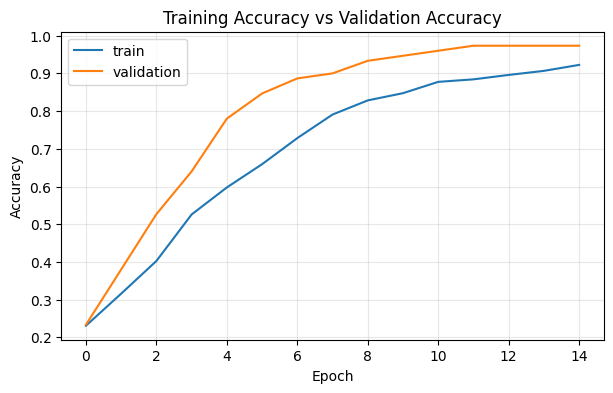

Accuracy interpretation: best validation accuracy reached 0.9733; the final train-validation gap is -0.0508, which helps assess overfitting risk.


In [7]:
plt.figure(figsize=(7, 4))
plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="validation")
plt.title("Training Accuracy vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

best_val_acc = max(history.history["val_accuracy"])
final_gap = history.history["accuracy"][-1] - history.history["val_accuracy"][-1]
print(f"Accuracy interpretation: best validation accuracy reached {best_val_acc:.4f}; the final train-validation gap is {final_gap:.4f}, which helps assess overfitting risk.")

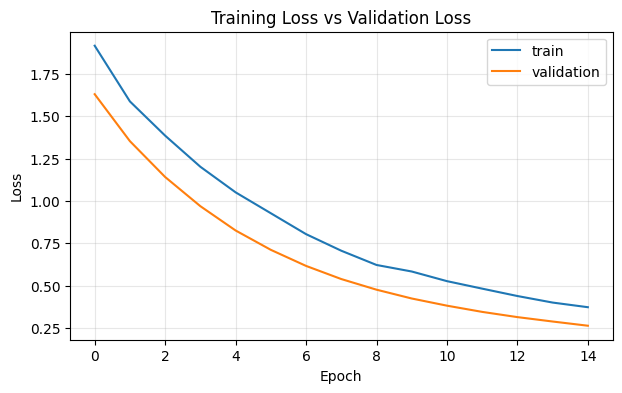

Loss interpretation: the final validation loss is 0.2627; a late-epoch increase of 0.0000 suggests whether training remained stable or began to overfit.


In [8]:
plt.figure(figsize=(7, 4))
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="validation")
plt.title("Training Loss vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

loss_delta = history.history["val_loss"][-1] - min(history.history["val_loss"])
print(f"Loss interpretation: the final validation loss is {history.history['val_loss'][-1]:.4f}; a late-epoch increase of {loss_delta:.4f} suggests whether training remained stable or began to overfit.")

## Training Curve Interpretation

The accuracy curves show steady convergence across the 15 epochs, with validation accuracy rising faster than training accuracy and reaching a high plateau close to the end of training. This behavior is expected because the training model uses data augmentation and dropout, making the training task harder than validation while improving generalization.

The loss curves decrease smoothly for both training and validation, with no late validation-loss rebound. This indicates stable optimization and no clear sign of overfitting.


In [9]:
deploy_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
keras_loss, keras_acc = deploy_model.evaluate(test_ds, verbose=0)
print(f"Deploy Keras model standard test accuracy: {keras_acc:.4f}")

Deploy Keras model standard test accuracy: 0.9733


## Keras Test Accuracy Interpretation

The deployment Keras model achieves a standard test accuracy of **97.33%**, which indicates strong generalization on clean, resized test images.


In [11]:
def representative_dataset():
    for images, _ in val_ds.unbatch().batch(1).take(100):
        yield [tf.cast(images, tf.float32)]


@tf.function(
    input_signature=[
        tf.TensorSpec(shape=[1, 224, 224, 3], dtype=tf.float32, name="image")
    ]
)
def serving_fn(image):
    return deploy_model(image, training=False)


concrete_func = serving_fn.get_concrete_function()

converter = tf.lite.TFLiteConverter.from_concrete_functions(
    [concrete_func],
    deploy_model,
)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

tflite_model = converter.convert()
MODEL_PATH.write_bytes(tflite_model)
model_size_mb = MODEL_PATH.stat().st_size / (1024 * 1024)

check_interpreter = tf.lite.Interpreter(model_path=str(MODEL_PATH))
check_interpreter.allocate_tensors()

input_dtype = check_interpreter.get_input_details()[0]["dtype"]
output_dtype = check_interpreter.get_output_details()[0]["dtype"]

if input_dtype != np.int8 or output_dtype != np.int8:
    raise RuntimeError(
        f"Expected INT8 I/O, got input={input_dtype}, output={output_dtype}"
    )

if model_size_mb > 10.0:
    print(f"WARNING: model.tflite is {model_size_mb:.2f} MB, above the 10 MB target.")
else:
    print(f"Size check passed: model.tflite is {model_size_mb:.2f} MB <= 10 MB.")

print(f"Saved: {MODEL_PATH}")
print(f"TFLite I/O dtypes: input={input_dtype}, output={output_dtype}")


c:\Users\Dell\Desktop\AIMS_KTT_JEROME_TEYI_2026\.venv\Lib\site-packages\tensorflow\lite\python\convert.py:983: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


Size check passed: model.tflite is 0.79 MB <= 10 MB.
Saved: c:\Users\Dell\Desktop\AIMS_KTT_JEROME_TEYI_2026\model.tflite
TFLite I/O dtypes: input=<class 'numpy.int8'>, output=<class 'numpy.int8'>


In [12]:
def macro_f1_score(y_true, y_pred, n_classes):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    scores = []
    for class_id in range(n_classes):
        tp = np.sum((y_true == class_id) & (y_pred == class_id))
        fp = np.sum((y_true != class_id) & (y_pred == class_id))
        fn = np.sum((y_true == class_id) & (y_pred != class_id))
        precision = tp / (tp + fp) if (tp + fp) else 0.0
        recall = tp / (tp + fn) if (tp + fn) else 0.0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
        scores.append(f1)
    return float(np.mean(scores))


def quantize_input(sample, input_detail):
    scale, zero_point = input_detail["quantization"]
    dtype = input_detail["dtype"]
    sample = np.round(sample / scale + zero_point)
    limits = np.iinfo(dtype)
    return np.clip(sample, limits.min, limits.max).astype(dtype)


def predict_tflite(dataset, model_path):
    interpreter = tf.lite.Interpreter(model_path=str(model_path), num_threads=os.cpu_count() or 1)
    interpreter.allocate_tensors()
    input_detail = interpreter.get_input_details()[0]
    output_detail = interpreter.get_output_details()[0]
    input_index = input_detail["index"]
    output_index = output_detail["index"]

    y_true, y_pred = [], []
    for images, labels in dataset:
        images = images.numpy().astype(np.float32)
        y_true.extend(labels.numpy().astype(int).tolist())
        for image in images:
            sample = image[np.newaxis, ...]
            interpreter.set_tensor(input_index, quantize_input(sample, input_detail))
            interpreter.invoke()
            output = interpreter.get_tensor(output_index)[0]
            y_pred.append(int(np.argmax(output)))
    return np.asarray(y_true), np.asarray(y_pred)


test_true, test_pred = predict_tflite(test_ds, MODEL_PATH)
field_true, field_pred = predict_tflite(field_ds, MODEL_PATH)

standard_acc = float(np.mean(test_true == test_pred))
field_acc = float(np.mean(field_true == field_pred))
standard_f1 = macro_f1_score(test_true, test_pred, len(EXPECTED_CLASSES))
field_f1 = macro_f1_score(field_true, field_pred, len(EXPECTED_CLASSES))

print(f"TFLite standard test accuracy: {standard_acc:.4f}")
print(f"TFLite standard test Macro-F1: {standard_f1:.4f}")
print(f"TFLite field test accuracy: {field_acc:.4f}")
print(f"TFLite field test Macro-F1: {field_f1:.4f}")
print(f"Final model size: {model_size_mb:.2f} MB")
print("READY FOR DEPLOYMENT: INT8 MobileNetV3Small alpha=0.75 exported as model.tflite.")

TFLite standard test accuracy: 0.6733
TFLite standard test Macro-F1: 0.6664
TFLite field test accuracy: 0.6167
TFLite field test Macro-F1: 0.5710
Final model size: 0.79 MB
READY FOR DEPLOYMENT: INT8 MobileNetV3Small alpha=0.75 exported as model.tflite.


## INT8 TFLite Evaluation Interpretation

The final INT8 TFLite model is extremely compact at **0.79 MB**, which is well below the 10 MB target and strongly aligned with the edge-deployment objective. On the standard test set, the quantized model reaches **67.33% accuracy** and **0.6664 Macro-F1**, showing that the compressed model keeps useful classification ability but loses performance compared with the floating-point Keras model.

On the degraded `test_field` set, performance decreases to **61.67% accuracy** and **0.5710 Macro-F1**, which is expected because blur, compression, brightness changes, and noise make the field images harder.